In [3]:
# ================================================================
# BAGIAN 1 — SETUP & KONFIGURASI
# ================================================================

# 1 Import Libraries
import os
import warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# 2 Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# 3 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ================================================================
# BAGIAN 2 — KONFIGURASI GLOBAL
# ================================================================

# Path dataset
BASE_PATH  = "/content/drive/MyDrive/Cat_Breed"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH   = os.path.join(BASE_PATH, "val")
TEST_PATH  = os.path.join(BASE_PATH, "test")
SAVE_PATH  = os.path.join(BASE_PATH, "saved_model")
os.makedirs(SAVE_PATH, exist_ok=True)

# Hyperparameter
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
NUM_CLASSES    = 5
EPOCHS_STAGE1  = 50
EPOCHS_STAGE2  = 30
LR_STAGE1      = 1e-4
LR_STAGE2      = 1e-5
LABEL_SMOOTHING = 0.1
LAST_CONV_LAYER = "block5_conv3"  # Layer target Grad-CAM

print(f"\n  Dataset    : {BASE_PATH}")
print(f"  Output     : {SAVE_PATH}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Label Smoothing : {LABEL_SMOOTHING}")


  Dataset    : /content/drive/MyDrive/Cat_Breed
  Output     : /content/drive/MyDrive/Cat_Breed/saved_model
  Batch size : 32
  Label Smoothing : 0.1


In [5]:
# ================================================================
# BAGIAN 3 — DATA LOADING & AUGMENTASI
# ================================================================

# Augmentasi HANYA untuk training — val/test cukup rescale
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Ambil class_names dari generator (urutan sesuai folder alphabetical)
CLASS_NAMES = list(train_generator.class_indices.keys())

print(f"\n  Total training : {train_generator.samples}")
print(f"  Total validasi : {val_generator.samples}")
print(f"  Total test     : {test_generator.samples}")
print(f"  Kelas          : {train_generator.class_indices}")

Found 1752 images belonging to 5 classes.
Found 375 images belonging to 5 classes.
Found 375 images belonging to 5 classes.

  Total training : 1752
  Total validasi : 375
  Total test     : 375
  Kelas          : {'Bombay': 0, 'Maine_Coon': 1, 'Scottish_Fold': 2, 'Siamese': 3, 'Sphynx': 4}


In [6]:
# ================================================================
# BAGIAN 4 — CLASS WEIGHT
# ================================================================
# Menyeimbangkan pengaruh kelas yang jumlah datanya tidak merata
# agar model tidak bias ke kelas mayoritas.

class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weight_array))
print(f"\n  Class Weights : {class_weight_dict}")


  Class Weights : {0: np.float64(1.0011428571428571), 1: np.float64(0.9954545454545455), 2: np.float64(1.0011428571428571), 3: np.float64(1.0011428571428571), 4: np.float64(1.0011428571428571)}


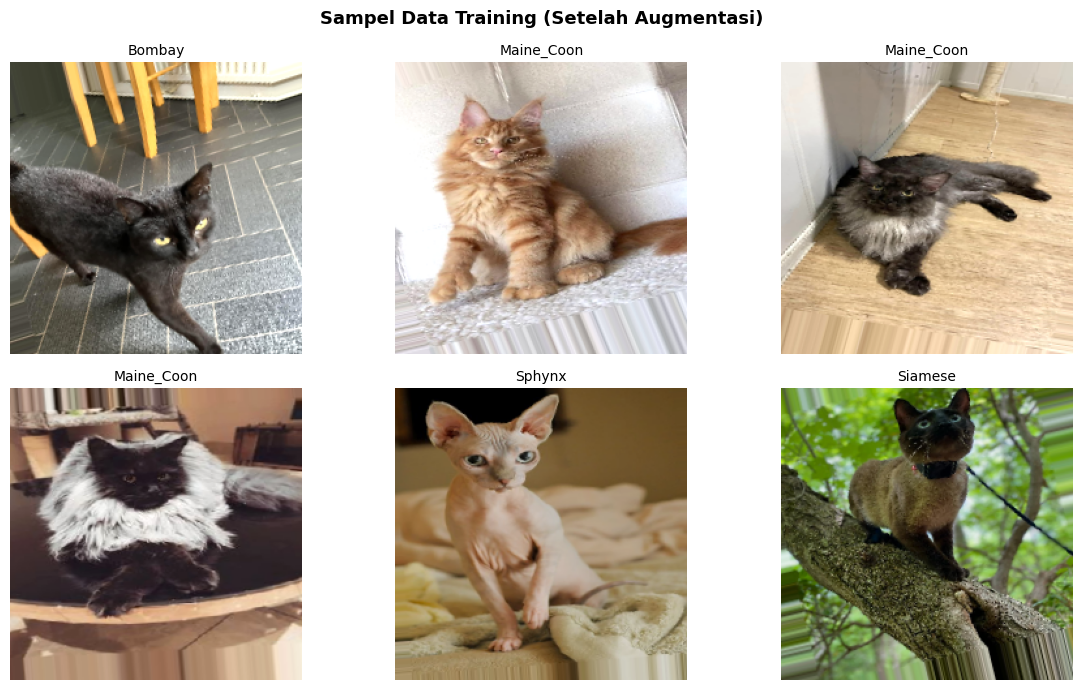

In [7]:
# ================================================================
# BAGIAN 5 — VISUALISASI SAMPEL DATA
# ================================================================

def visualize_samples(generator, class_names, n=6):
    """Menampilkan n sampel gambar beserta label kelasnya."""
    images, labels = next(generator)
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig.suptitle("Sampel Data Training (Setelah Augmentasi)",
                 fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < n and i < len(images):
            ax.imshow(images[i])
            ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'sample_data.png'), dpi=120, bbox_inches='tight')
    plt.show()

visualize_samples(train_generator, CLASS_NAMES)

In [8]:
# ================================================================
# BAGIAN 6 — ARSITEKTUR MODEL
# ================================================================

def build_model(num_classes: int) -> tuple:
    """
    Membangun model VGG16 + custom classification head.

    Arsitektur head:
      GAP → BatchNorm → Dense(256, L2) → Dropout(0.5)
           → Dense(128, L2) → Dropout(0.3) → Softmax(num_classes)

    Returns:
        model      : Model lengkap (siap compile)
        base_model : Referensi ke VGG16 base (untuk fine-tuning)
    """
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Stage 1: semua layer VGG16 dibekukan
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)
    return model, base_model


model, base_model = build_model(NUM_CLASSES)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n  Total parameter     : {model.count_params():,}")
print(f"  Parameter trainable : {trainable_params:,}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,881,605 (56.77 MB)

 Trainable params: 165,893 (648.02 KB)

 Non-trainable params: 14,715,712 (56.14 MB)


  Total parameter     : 14,881,605
  Parameter trainable : 165,893


In [9]:
# ================================================================
# BAGIAN 7 — BUILDER CALLBACKS (Fungsi, bukan duplikasi)
# ================================================================
# Dibuat sebagai fungsi agar tidak ada duplikasi kode antara

def build_callbacks(stage: int, save_path: str) -> list:
    """
    Membangun daftar callback untuk satu stage training.

    Callback yang digunakan:
    - EarlyStopping    : Hentikan training jika val_loss tidak membaik
    - ReduceLROnPlateau: Turunkan LR saat training stagnan
    - ModelCheckpoint  : Simpan bobot terbaik otomatis
    - CSVLogger        : [BARU] Catat semua metrik per epoch ke file CSV
    """
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            patience=3,
            factor=0.5,
            min_lr=1e-8,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(save_path, f'best_stage{stage}.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),

        CSVLogger(
            filename=os.path.join(save_path, f'training_log_stage{stage}.csv'),
            append=False
        ),
    ]

In [10]:
# ================================================================
# BAGIAN 8 — TRAINING STAGE 1 (Head Only)
# ================================================================

print("\n" + "=" * 60)
print("  STAGE 1 — Training Classification Head")
print("  (Semua layer VGG16 dibekukan)")
print("=" * 60)

history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE1,
    callbacks=build_callbacks(stage=1, save_path=SAVE_PATH),
    class_weight=class_weight_dict,
    verbose=1
)


  STAGE 1 — Training Classification Head
  (Semua layer VGG16 dibekukan)
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.2104 - loss: 2.0766 
Epoch 1: val_accuracy improved from None to 0.22133, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1222s 22s/step - accuracy: 0.2340 - loss: 1.9828 - val_accuracy: 0.2213 - val_loss: 1.6683 - learning_rate: 1.0000e-04
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.3136 - loss: 1.7142
Epoch 2: val_accuracy improved from 0.22133 to 0.32000, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.3408 - loss: 1.6597 - val_accuracy: 0.3200 - val_loss: 1.5902 - learning_rate: 1.0000e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.4456 - loss: 1.4876
Epoch 3: val_accuracy improved from 0.32000 to 0.53067, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4646 - loss: 1.4505 - val_accuracy: 0.5307 - val_loss: 1.5016 - learning_rate: 1.0000e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.5139 - loss: 1.3497
Epoch 4: val_accuracy improved from 0.53067 to 0.68533, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5046 - loss: 1.3712 - val_accuracy: 0.6853 - val_loss: 1.3878 - learning_rate: 1.0000e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.5614 - loss: 1.2834
Epoch 5: val_accuracy improved from 0.68533 to 0.74933, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5


...


Epoch 33: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8299 - loss: 0.8349 - val_accuracy: 0.9093 - val_loss: 0.7082 - learning_rate: 1.0000e-04
Epoch 34/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.8294 - loss: 0.8245
Epoch 34: val_accuracy did not improve from 0.90933
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8322 - loss: 0.8283 - val_accuracy: 0.9093 - val_loss: 0.7084 - learning_rate: 1.0000e-04
Epoch 35/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.8363 - loss: 0.8069
Epoch 35: val_accuracy did not improve from 0.90933
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8408 - loss: 0.8046 - val_accuracy: 0.9067 - val_loss: 0.7068 - learning_rate: 1.0000e-04
Epoch 36/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.8389 - loss: 0.8201
Epoch 36: val_accuracy improved from 0.90933 to 0.91200, saving model to /content/drive/MyDrive/Cat_Breed/save


Epoch 36: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8368 - loss: 0.8189 - val_accuracy: 0.9120 - val_loss: 0.7049 - learning_rate: 1.0000e-04
Epoch 37/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.8247 - loss: 0.8351
Epoch 37: val_accuracy improved from 0.91200 to 0.91467, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5



Epoch 37: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8305 - loss: 0.8144 - val_accuracy: 0.9147 - val_loss: 0.7042 - learning_rate: 1.0000e-04
Epoch 38/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.8512 - loss: 0.8053
Epoch 38: val_accuracy did not improve from 0.91467
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8459 - loss: 0.8010 - val_accuracy: 0.9147 - val_loss: 0.7014 - learning_rate: 1.0000e-04
Epoch 39/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.8511 - loss: 0.7737
Epoch 39: val_accuracy did not improve from 0.91467
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8419 - loss: 0.8011 - val_accuracy: 0.9120 - val_loss: 0.7015 - learning_rate: 1.0000e-04
Epoch 40/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.8546 - loss: 0.7946
Epoch 40: val_accuracy did not improve from 0.91467
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8505 


Epoch 41: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8482 - loss: 0.7837 - val_accuracy: 0.9173 - val_loss: 0.7007 - learning_rate: 1.0000e-04
Epoch 42/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.8564 - loss: 0.7702
Epoch 42: val_accuracy did not improve from 0.91733
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8482 - loss: 0.7825 - val_accuracy: 0.9147 - val_loss: 0.6988 - learning_rate: 1.0000e-04
Epoch 43/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.8538 - loss: 0.7872
Epoch 43: val_accuracy did not improve from 0.91733
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8573 - loss: 0.7850 - val_accuracy: 0.9147 - val_loss: 0.6956 - learning_rate: 1.0000e-04
Epoch 44/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.8658 - loss: 0.7759
Epoch 44: val_accuracy did not improve from 0.91733
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8607 


Epoch 49: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage1.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8664 - loss: 0.7638 - val_accuracy: 0.9227 - val_loss: 0.6859 - learning_rate: 1.0000e-04
Epoch 50/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8572 - loss: 0.7785
Epoch 50: val_accuracy did not improve from 0.92267
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8647 - loss: 0.7699 - val_accuracy: 0.9227 - val_loss: 0.6841 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 50.


In [11]:
# ================================================================
# BAGIAN 9 — FINE-TUNING STAGE 2 (Block 4 & 5 VGG16)
# ================================================================
# Strategi unfreeze berbasis BLOCK, bukan jumlah layer.
#
# Penjelasan pendekatan block-based:
# VGG16 terdiri dari 5 convolutional block:
#   Block 1-2 : Fitur sangat umum (tepi, warna) → tetap FROZEN
#   Block 3   : Fitur tekstur dasar              → tetap FROZEN
#   Block 4   : Fitur tekstur kompleks (bulu)    → UNFREEZE
#   Block 5   : Fitur objek tingkat tinggi        → UNFREEZE

print("\n" + "=" * 60)
print("  STAGE 2 — Fine-Tuning Block 4 & 5 VGG16")
print("  (Block 1, 2, 3 tetap frozen)")
print("=" * 60)

UNFREEZE_FROM_BLOCK = ['block4', 'block5']

for layer in base_model.layers:

    should_unfreeze = any(block in layer.name for block in UNFREEZE_FROM_BLOCK)
    layer.trainable = should_unfreeze

print("\n  Layer yang di-unfreeze untuk fine-tuning:")
for layer in base_model.layers:
    if layer.trainable:
        print(f"    ✅ {layer.name}")

trainable_params_ft = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n  Parameter trainable setelah unfreeze: {trainable_params_ft:,}")

# Recompile dengan LR 10x lebih kecil dari Stage 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=loss_fn,
    metrics=['accuracy']
)

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE2,
    callbacks=build_callbacks(stage=2, save_path=SAVE_PATH),
    class_weight=class_weight_dict,
    verbose=1
)

# Simpan model final
final_model_path = os.path.join(SAVE_PATH, 'vgg16_catbreed_final.h5')
model.save(final_model_path)
print(f"\n Model final tersimpan: {final_model_path}")


  STAGE 2 — Fine-Tuning Block 4 & 5 VGG16
  (Block 1, 2, 3 tetap frozen)

  Layer yang di-unfreeze untuk fine-tuning:
    ✅ block4_conv1
    ✅ block4_conv2
    ✅ block4_conv3
    ✅ block4_pool
    ✅ block5_conv1
    ✅ block5_conv2
    ✅ block5_conv3
    ✅ block5_pool

  Parameter trainable setelah unfreeze: 13,145,093
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8807 - loss: 0.7409
Epoch 1: val_accuracy improved from None to 0.94400, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8813 - loss: 0.7418 - val_accuracy: 0.9440 - val_loss: 0.6488 - learning_rate: 1.0000e-05
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9200 - loss: 0.6768
Epoch 2: val_accuracy improved from 0.94400 to 0.95200, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9264 - loss: 0.6710 - val_accuracy: 0.9520 - val_loss: 0.6216 - learning_rate: 1.0000e-05
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9248 - loss: 0.6862
Epoch 3: val_accuracy improved from 0.95200 to 0.95467, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9275 - loss: 0.6768 - val_accuracy: 0.9547 - val_loss: 0.6057 - learning_rate: 1.0000e-05
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9486 - loss: 0.6414
Epoch 4: val_accuracy did not improve from 0.95467
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9406 - loss: 0.6457 - val_accuracy: 0.9520 - val_loss: 0.5929 - learning_rate: 1.0000e-05
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.9501 - loss: 0.6288
Epoch 5: val_accuracy improved from 0.95467 to 0.96000, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9481 - loss: 0.6347 - val_accuracy: 0.9600 - val_loss: 0.5914 - learning_rate: 1.0000e-05
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9613 - loss: 0.6110
Epoch 6: val_accuracy did not improve from 0.96000
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9583 - loss: 0.6142 - val_accuracy: 0.9547 - val_loss: 0.5708 - learning_rate: 1.0000e-05
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.9561 - loss: 0.6133
Epoch 7: val_accuracy did not improve from 0.96000
55/55 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9543 - loss: 0.6131 - val_accuracy: 0.9547 - val_loss: 0.5947 - learning_rate: 1.0000e-05
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.9677 - loss: 0.5991
Epoch 8: val_accuracy improved from 0.96000 to 0.96533, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/be

...


Epoch 15: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9886 - loss: 0.5550 - val_accuracy: 0.9787 - val_loss: 0.5390 - learning_rate: 1.0000e-05
Epoch 16/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9875 - loss: 0.5584
Epoch 16: val_accuracy did not improve from 0.97867
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9852 - loss: 0.5606 - val_accuracy: 0.9680 - val_loss: 0.5329 - learning_rate: 1.0000e-05
Epoch 17/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.9866 - loss: 0.5548
Epoch 17: val_accuracy improved from 0.97867 to 0.98133, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 17: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9874 - loss: 0.5511 - val_accuracy: 0.9813 - val_loss: 0.5358 - learning_rate: 1.0000e-05
Epoch 18/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9868 - loss: 0.5613
Epoch 18: val_accuracy improved from 0.98133 to 0.98400, saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5



Epoch 18: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9874 - loss: 0.5538 - val_accuracy: 0.9840 - val_loss: 0.5262 - learning_rate: 1.0000e-05
Epoch 19/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9874 - loss: 0.5468
Epoch 19: val_accuracy did not improve from 0.98400
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9869 - loss: 0.5515 - val_accuracy: 0.9787 - val_loss: 0.5261 - learning_rate: 1.0000e-05
Epoch 20/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 981ms/step - accuracy: 0.9863 - loss: 0.5487
Epoch 20: val_accuracy did not improve from 0.98400
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9857 - loss: 0.5479 - val_accuracy: 0.9733 - val_loss: 0.5548 - learning_rate: 1.0000e-05
Epoch 21/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.9891 - loss: 0.5410
Epoch 21: val_accuracy did not improve from 0.98400
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9880 - l


Epoch 24: finished saving model to /content/drive/MyDrive/Cat_Breed/saved_model/best_stage2.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9960 - loss: 0.5324 - val_accuracy: 0.9893 - val_loss: 0.5197 - learning_rate: 1.0000e-05
Epoch 25/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9961 - loss: 0.5298
Epoch 25: val_accuracy did not improve from 0.98933
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9943 - loss: 0.5298 - val_accuracy: 0.9867 - val_loss: 0.5201 - learning_rate: 5.0000e-06
Epoch 26/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.9949 - loss: 0.5339
Epoch 26: val_accuracy did not improve from 0.98933
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9937 - loss: 0.5329 - val_accuracy: 0.9840 - val_loss: 0.5220 - learning_rate: 5.0000e-06
Epoch 27/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9945 - loss: 0.5310   
Epoch 27: val_accuracy did not improve from 0.98933
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9932 - l


 Model final tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/vgg16_catbreed_final.h5


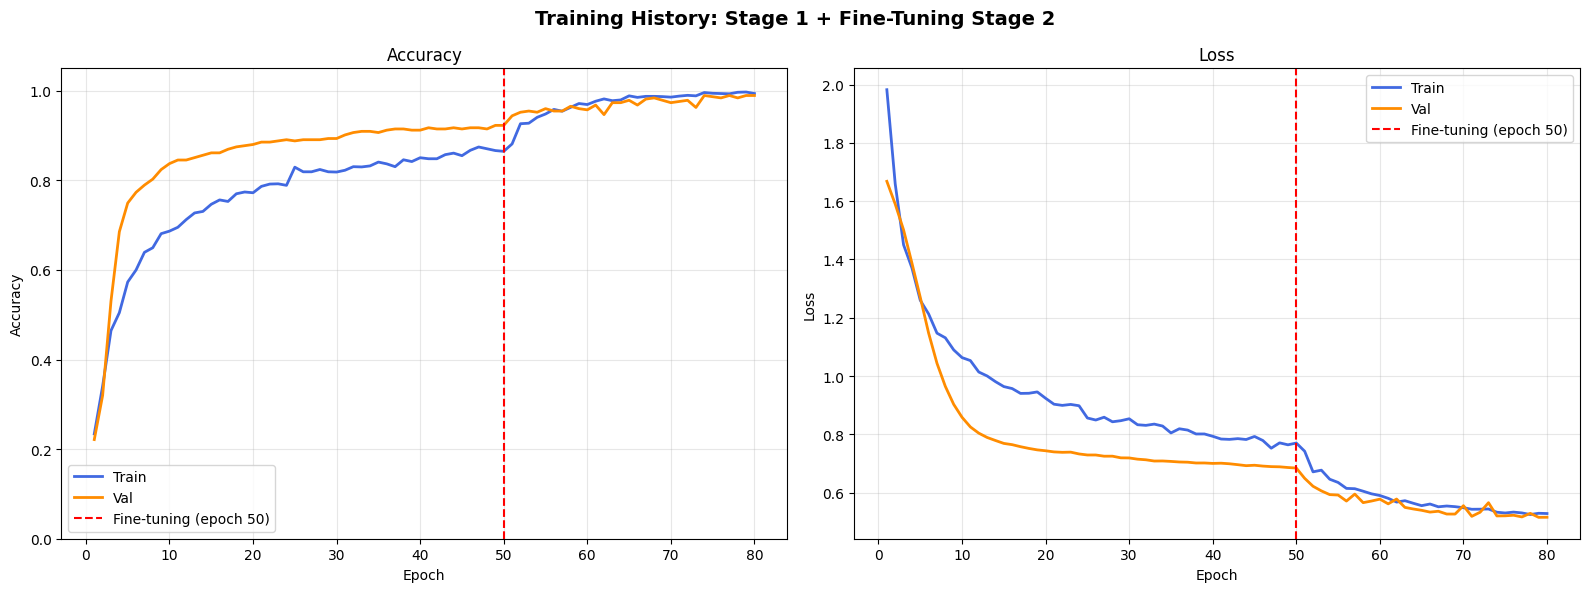

  ✅ Grafik history tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/training_history.png


In [12]:
# ================================================================
# BAGIAN 10 — VISUALISASI TRAINING HISTORY
# ================================================================

def plot_combined_history(hist1, hist2, save_path: str):
    """
    Menggabungkan history Stage 1 & 2 dalam satu grafik.
    Garis putus-putus merah menandai titik dimulainya fine-tuning.
    """
    acc      = hist1.history['accuracy']     + hist2.history['accuracy']
    val_acc  = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss     = hist1.history['loss']         + hist2.history['loss']
    val_loss = hist1.history['val_loss']     + hist2.history['val_loss']

    ft_start     = len(hist1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Training History: Stage 1 + Fine-Tuning Stage 2",
                 fontsize=14, fontweight='bold')

    for ax, (train_data, val_data, title, ylabel) in zip(
        axes,
        [
            (acc, val_acc, "Accuracy", "Accuracy"),
            (loss, val_loss, "Loss", "Loss"),
        ]
    ):
        ax.plot(epochs_range, train_data, label='Train', color='royalblue', linewidth=2)
        ax.plot(epochs_range, val_data,   label='Val',   color='darkorange', linewidth=2)
        ax.axvline(x=ft_start, color='red', linestyle='--', linewidth=1.5,
                   label=f'Fine-tuning (epoch {ft_start})')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylim([0, 1.05])

    plt.tight_layout()
    out = os.path.join(save_path, 'training_history.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Grafik history tersimpan: {out}")


plot_combined_history(history_stage1, history_stage2, SAVE_PATH)

In [13]:
# ================================================================
# BAGIAN 11 — EVALUASI MODEL
# ================================================================

print("\n" + "=" * 60)
print("  EVALUASI MODEL PADA TEST SET")
print("=" * 60)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")

# --- Prediksi ---
print("\n  Menjalankan prediksi...")
preds        = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes
class_names  = list(test_generator.class_indices.keys())

# --- Classification Report ---
print("\n" + "=" * 60)
print("  CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(true_classes, pred_classes, target_names=class_names))


  EVALUASI MODEL PADA TEST SET
12/12 ━━━━━━━━━━━━━━━━━━━━ 214s 19s/step - accuracy: 0.9733 - loss: 0.5311

  Test Loss     : 0.5311
  Test Accuracy : 0.9733  (97.33%)

  Menjalankan prediksi...
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 578ms/step

  CLASSIFICATION REPORT
               precision    recall  f1-score   support

       Bombay       1.00      0.99      0.99        75
   Maine_Coon       0.95      0.99      0.97        75
Scottish_Fold       0.99      0.96      0.97        75
      Siamese       0.97      0.96      0.97        75
       Sphynx       0.96      0.97      0.97        75

     accuracy                           0.97       375
    macro avg       0.97      0.97      0.97       375
 weighted avg       0.97      0.97      0.97       375



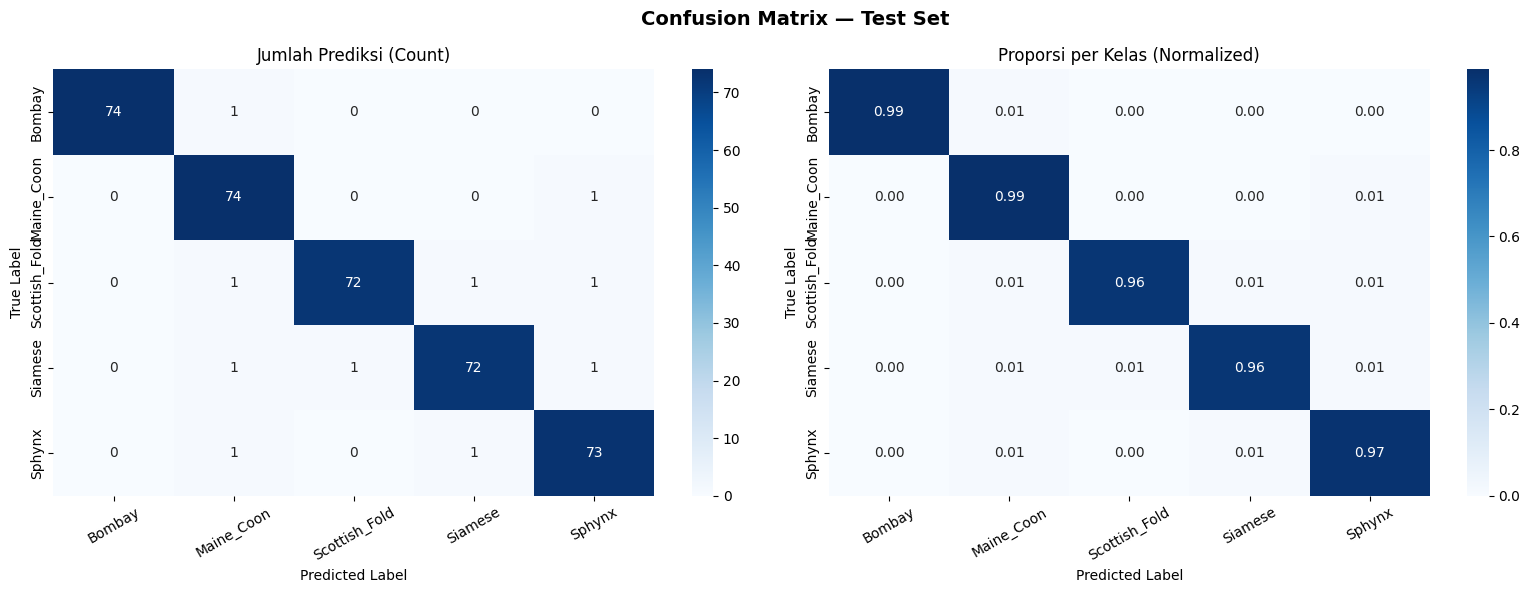

  Confusion matrix tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/confusion_matrix.png


In [14]:
# ================================================================
# BAGIAN 12 — CONFUSION MATRIX
# ================================================================

def plot_confusion_matrix(true_cls, pred_cls, class_names: list, save_path: str):
    """Menampilkan confusion matrix dalam dua versi: count & normalized."""
    cm            = confusion_matrix(true_cls, pred_cls)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight='bold')

    params = [
        (cm,            'd',    "Jumlah Prediksi (Count)"),
        (cm_normalized, '.2f',  "Proporsi per Kelas (Normalized)"),
    ]
    for ax, (data, fmt, title) in zip(axes, params):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title)
        ax.set_ylabel("True Label")
        ax.set_xlabel("Predicted Label")
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    out = os.path.join(save_path, 'confusion_matrix.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Confusion matrix tersimpan: {out}")


plot_confusion_matrix(true_classes, pred_classes, class_names, SAVE_PATH)

  Visualisasi prediksi tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/sample_predictions.png


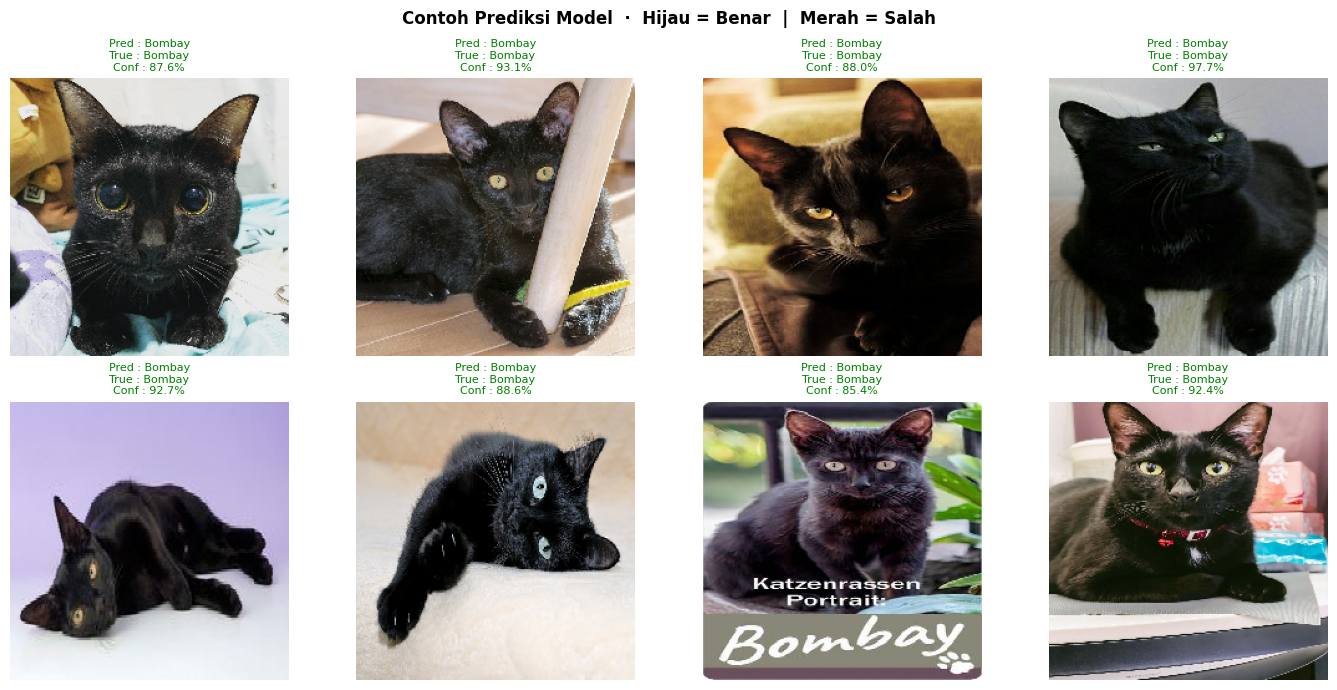

In [15]:
# ================================================================
# BAGIAN 13 — VISUALISASI PREDIKSI (BENAR & SALAH)
# ================================================================

def plot_predictions(generator, model, class_names: list,
                     n: int = 8, save_path: str = ""):
    """
    Menampilkan n sampel prediksi dari test generator.
    Label hijau = benar, merah = salah.
    Border warna memperjelas status prediksi secara visual.
    """
    images, labels = next(generator)
    p           = model.predict(images, verbose=0)
    pred_idx    = np.argmax(p, axis=1)
    true_idx    = np.argmax(labels, axis=1)

    n    = min(n, len(images))
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    fig.suptitle("Contoh Prediksi Model  ·  Hijau = Benar  |  Merah = Salah",
                 fontsize=12, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(images[i])
            color = 'green' if pred_idx[i] == true_idx[i] else 'red'
            ax.set_title(
                f"Pred : {class_names[pred_idx[i]]}\n"
                f"True : {class_names[true_idx[i]]}\n"
                f"Conf : {p[i][pred_idx[i]]:.1%}",
                color=color, fontsize=8
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        out = os.path.join(save_path, 'sample_predictions.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Visualisasi prediksi tersimpan: {out}")
    plt.show()


plot_predictions(test_generator, model, class_names, save_path=SAVE_PATH)

  Grad-CAM tersimpan: /content/drive/MyDrive/Cat_Breed/saved_model/gradcam_visualization.png


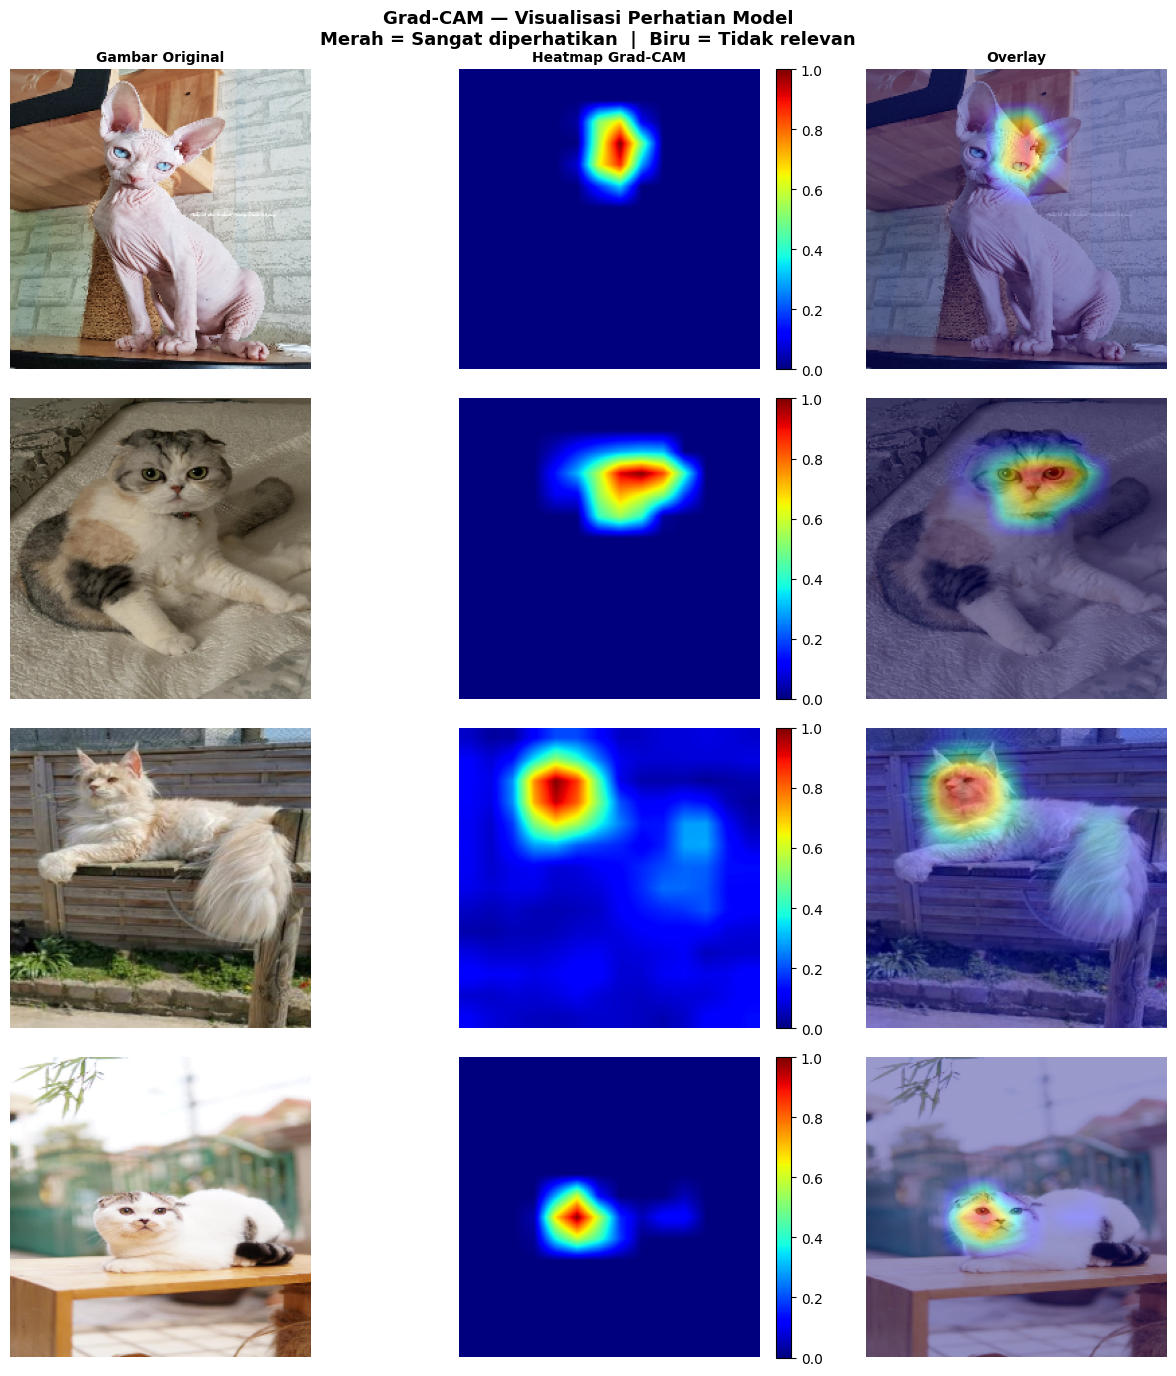

In [16]:
# ================================================================
# BAGIAN 14 — GRAD-CAM
# ================================================================

def make_gradcam_heatmap(img_array: np.ndarray,
                         model,
                         last_conv_layer_name: str) -> tuple:
    """
    Menghasilkan heatmap Grad-CAM dari layer konvolusi target.

    Args:
        img_array           : Array gambar (1, H, W, 3), sudah ternormalisasi
        model               : Model Keras yang sudah dilatih
        last_conv_layer_name: Nama layer konvolusi terakhir

    Returns:
        heatmap     : Array 2D ternormalisasi [0, 1]
        pred_class  : Indeks kelas yang diprediksi
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        loss       = predictions[:, pred_class]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap).numpy()

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, int(pred_class.numpy())


def overlay_gradcam(img_path: str, heatmap: np.ndarray,
                    target_size: tuple, alpha: float = 0.4) -> tuple:
    """
    Menggabungkan heatmap Grad-CAM dengan gambar asli.

    Returns:
        img_rgb       : Gambar asli (RGB)
        heatmap_2d    : Heatmap yang sudah di-resize
        superimposed  : Overlay gambar + heatmap
    """
    img_bgr  = cv2.resize(cv2.imread(img_path), target_size)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    hm       = cv2.resize(heatmap, target_size)
    hm_color = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm_rgb   = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_rgb, 1 - alpha, hm_rgb, alpha, 0)
    return img_rgb, hm, superimposed


def visualize_gradcam_batch(generator, model, class_names: list,
                            n_samples: int = 4,
                            last_conv_layer: str = LAST_CONV_LAYER,
                            save_path: str = ""):
    """
    Visualisasi Grad-CAM untuk n_samples gambar dari generator.
    Kolom: Original | Heatmap | Overlay
    """
    filepaths    = generator.filepaths
    true_cls_all = generator.classes
    indices      = np.random.choice(len(filepaths), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(13, n_samples * 3.5))
    fig.suptitle(
        "Grad-CAM — Visualisasi Perhatian Model\n"
        "Merah = Sangat diperhatikan  |  Biru = Tidak relevan",
        fontsize=13, fontweight='bold'
    )

    # Header kolom
    for ax, title in zip(axes[0], ["Gambar Original", "Heatmap Grad-CAM", "Overlay"]):
        ax.set_title(title, fontweight='bold', fontsize=10)

    for row, idx in enumerate(indices):
        img_path   = filepaths[idx]
        true_label = class_names[true_cls_all[idx]]

        img       = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = np.expand_dims(
            tf.keras.utils.img_to_array(img) / 255.0, axis=0
        )

        heatmap, pred_idx         = make_gradcam_heatmap(img_array, model, last_conv_layer)
        pred_label                = class_names[pred_idx]
        img_orig, hm, overlay     = overlay_gradcam(img_path, heatmap, IMG_SIZE)
        color                     = 'green' if true_label == pred_label else 'red'

        axes[row, 0].imshow(img_orig)
        axes[row, 0].set_ylabel(
            f"True : {true_label}\nPred : {pred_label}",
            fontsize=8, color=color
        )
        axes[row, 0].axis('off')

        im = axes[row, 1].imshow(hm, cmap='jet', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].axis('off')

    plt.tight_layout()
    if save_path:
        out = os.path.join(save_path, 'gradcam_visualization.png')
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Grad-CAM tersimpan: {out}")
    plt.show()


visualize_gradcam_batch(test_generator, model, class_names, save_path=SAVE_PATH)

In [17]:
# ================================================================
# BAGIAN 15 — RINGKASAN HASIL AKHIR
# ================================================================

best_val_s1 = max(history_stage1.history['val_accuracy'])
best_val_s2 = max(history_stage2.history['val_accuracy'])
best_val    = max(best_val_s1, best_val_s2)
target_met  = "ERCAPAI" if test_acc >= 0.80 else "BELUM TERCAPAI"

print("\n" + "=" * 60)
print("  RINGKASAN HASIL AKHIR TRAINING")
print("=" * 60)
print(f"  Best Val Accuracy  Stage 1  : {best_val_s1:.4f}  ({best_val_s1*100:.2f}%)")
print(f"  Best Val Accuracy  Stage 2  : {best_val_s2:.4f}  ({best_val_s2*100:.2f}%)")
print(f"  Best Val Accuracy  Overall  : {best_val:.4f}  ({best_val*100:.2f}%)")
print(f"  Test Accuracy               : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Loss                   : {test_loss:.4f}")
print(f"  Target ≥ 80%                : {target_met}")
print(f"\n  File tersimpan di           : {SAVE_PATH}")
print(f"    ├── best_stage1.h5")
print(f"    ├── best_stage2.h5")
print(f"    ├── vgg16_catbreed_final.h5")
print(f"    ├── training_log_stage1.csv      ← [BARU] Log training per epoch")
print(f"    ├── training_log_stage2.csv      ← [BARU] Log fine-tuning per epoch")
print(f"    ├── training_history.png")
print(f"    ├── confusion_matrix.png")
print(f"    ├── sample_predictions.png")
print(f"    ├── gradcam_visualization.png")
print(f"    └── sample_data.png")
print("=" * 60)


  RINGKASAN HASIL AKHIR TRAINING
  Best Val Accuracy  Stage 1  : 0.9227  (92.27%)
  Best Val Accuracy  Stage 2  : 0.9893  (98.93%)
  Best Val Accuracy  Overall  : 0.9893  (98.93%)
  Test Accuracy               : 0.9733  (97.33%)
  Test Loss                   : 0.5311
  Target ≥ 80%                : ERCAPAI

  File tersimpan di           : /content/drive/MyDrive/Cat_Breed/saved_model
    ├── best_stage1.h5
    ├── best_stage2.h5
    ├── vgg16_catbreed_final.h5
    ├── training_log_stage1.csv      ← [BARU] Log training per epoch
    ├── training_log_stage2.csv      ← [BARU] Log fine-tuning per epoch
    ├── training_history.png
    ├── confusion_matrix.png
    ├── sample_predictions.png
    ├── gradcam_visualization.png
    └── sample_data.png
